In [2]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 100
plt.rcParams['font.size'] = 10
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.left'] = True
plt.rcParams['axes.spines.bottom'] = True
plt.rcParams['axes.grid'] = False
plt.rcParams['legend.frameon'] = False
plt.rcParams['legend.loc'] = 'best'

plt.rcParams['legend.fontsize'] = 10
plt.rcParams['legend.title_fontsize'] = 10
plt.rcParams['xtick.labelsize'] = 8  # Taille des labels des xticks
plt.rcParams['ytick.labelsize'] = 8  # Taille des labels des yticks
plt.rcParams['legend.fontsize'] = 8 # Taille des labels de la légende
plt.rcParams['figure.titlesize'] = 12  # Taille du titre de la figure
plt.rcParams['axes.titlesize'] = 12  # Taille du titre des sous-graphes
plt.rcParams['axes.labelsize'] = 10  # Taille des labels des axes







path="/media/nicolascatz/ssdcalcul/Projets/M1_NEURO_APP_NC"
path="D:/DATA/Projets/M1_NEURO_APP_NC"

pathresults=path+"/out/"
pathscripts=path+"/scripts/"

file=np.load(pathresults+"FileAll.npz", allow_pickle=True)["arr_0"]
unit=np.load(pathresults+"UnitAll.npz", allow_pickle=True)["arr_0"]

In [3]:
print(unit.shape)
print("nb of units: ", file.shape[0])


(918,)
nb of units:  918


In [4]:
nbunits = unit.shape[0]
nbunits

918

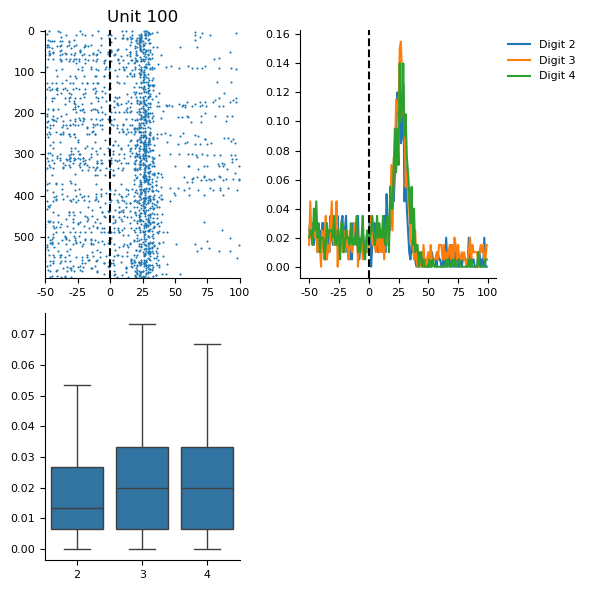

In [5]:
import scipy.stats as stats
import seaborn as sns


n=100

fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(6,6))
ax_flat = ax.flatten()

ax_flat[0].spy(unit[n][:,50:200],aspect='auto',markersize=0.5)
ax_flat[0].xaxis.set_ticks_position('bottom')
ax_flat[0].axvline(x=50, color='k', linestyle='--')
ax_flat[0].set_title("Unit "+str(n))
ax_flat[0].set_xticks([0,25,50,75,100,125,150])
ax_flat[0].set_xticklabels([-50, -25, 0, 25, 50, 75, 100])

ax_flat[1].plot(unit[n][unit[n][:,0]==2][:,50:200].mean(axis=0), label="Digit 2")
ax_flat[1].plot(unit[n][unit[n][:,0]==3][:,50:200].mean(axis=0), label="Digit 3")
ax_flat[1].plot(unit[n][unit[n][:,0]==4][:,50:200].mean(axis=0), label="Digit 4")
ax_flat[1].legend(frameon=False, bbox_to_anchor=(1.01, 1), loc='upper left')
ax_flat[1].axvline(x=50, color='k', linestyle='--')

ax_flat[1].set_xticks([0,25,50,75,100,125,150])
ax_flat[1].set_xticklabels([-50, -25, 0, 25, 50, 75, 100])

ax_flat[1].spines['right'].set_visible(False)
ax_flat[1].spines['top'].set_visible(False)




sns.boxplot(x=unit[n][:,0], y=unit[n][:,50:200].mean(axis=1), ax=ax_flat[2],showfliers=False)
ax_flat[2].spines['right'].set_visible(False)
ax_flat[2].spines['top'].set_visible(False)
ax_flat[3].axis('off')
plt.tight_layout()
plt.show()

Prepare data for 2 3 4 decoding

In [6]:
import random
UnitPop=[]
for n in range(nbunits):

    unit2=unit[n][unit[n][:,0]==2][:,50:200]
    unit3=unit[n][unit[n][:,0]==3][:,50:200]
    unit4=unit[n][unit[n][:,0]==4][:,50:200]

    if unit2.shape[0] > 100 and unit3.shape[0] > 100 and unit4.shape[0] > 100:
        unit300=np.concatenate((unit2[random.sample(range(unit2.shape[0]), 100),:],
                            unit3[random.sample(range(unit3.shape[0]), 100),:],
                            unit4[random.sample(range(unit4.shape[0]), 100),:]), axis=0)
        

        UnitTime=np.sum(unit300[:,60:100], axis=1) # sum spikes in the time window

        UnitTime[UnitTime>0]=1 # binarize    


        UnitPop.extend([UnitTime])


StimTarget = [2] * 100
StimTarget.extend([3] * 100)
StimTarget.extend([4] * 100)
print(StimTarget)

UnitPop=np.array(UnitPop)
UnitPop=UnitPop.T
print(UnitPop.shape)

[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4]
(300, 795)


decoding control data

Mean Accuracy:  0.9649999999999999
Mean Accuracy Shuffled:  0.3288888888888889


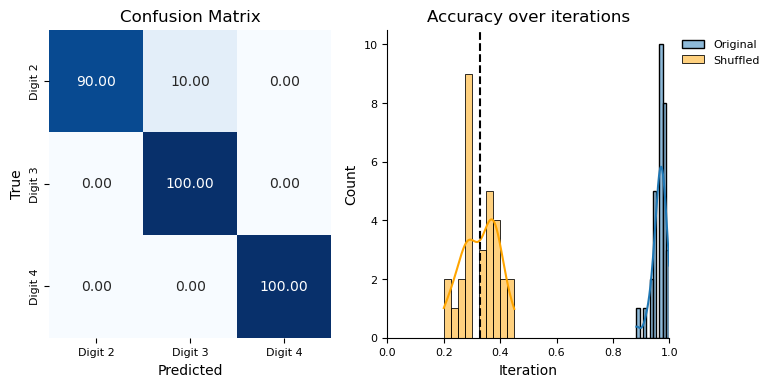

In [12]:
import numpy as np
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

X = UnitPop[:,:]
y = StimTarget

CM=np.zeros((3,3))
AccuracyAll=[]
for i in range(30):
    # Diviser les données en ensembles d'entraînement et de test
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=i)
    accuracy = []
    # Créer et entraîner le modèle KNN
    knn = KNeighborsClassifier(n_neighbors=17)
    knn.fit(X_train, y_train)

    # Faire des prédictions sur l'ensemble de test
    y_pred = knn.predict(X_test)

    # Évaluer la performance du modèle
    AccuracyAll.append(accuracy_score(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    CM+=cm

AccuracyAllShuff=[]
for i in range(30):
    # Diviser les données en ensembles d'entraînement et de test
    X_train, X_test, y_train, y_test = train_test_split(X, np.random.permutation(y), test_size=0.2, random_state=i)
    accuracy = []
    # Créer et entraîner le modèle KNN
    knn = KNeighborsClassifier(n_neighbors=17)
    knn.fit(X_train, y_train)

    # Faire des prédictions sur l'ensemble de test
    y_pred = knn.predict(X_test)

    # Évaluer la performance du modèle
    AccuracyAllShuff.append(accuracy_score(y_test, y_pred))

  

print("Mean Accuracy: ", np.mean(AccuracyAll))
print("Mean Accuracy Shuffled: ", np.mean(AccuracyAllShuff))

cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, ax = plt.subplots(figsize=(8,4),nrows=1,ncols=2)
sns.heatmap(cm_normalized*100, annot=True, fmt='.2f',cmap='Blues',
            xticklabels=['Digit 2', 'Digit 3', 'Digit 4'],
            yticklabels=['Digit 2', 'Digit 3', 'Digit 4'],
            cbar=False, ax=ax[0])

ax[0].set_xlabel('Predicted')
ax[0].set_ylabel('True')
ax[0].set_title('Confusion Matrix')
sns.histplot(AccuracyAll, ax=ax[1], bins=10, kde=True, label='Original')
sns.histplot(AccuracyAllShuff, ax=ax[1], bins=10, kde=True, color='orange', label='Shuffled')
ax[1].legend(frameon=False, bbox_to_anchor=(1.01, 1), loc='upper left')
ax[1].set_title('Accuracy over iterations')
ax[1].set_xlabel('Iteration')
ax[1].set_xlim(0, 1)
ax[1].axvline(x=0.33, color='k', linestyle='--', label='Chance Level')
plt.show()

Validation curve du KNN

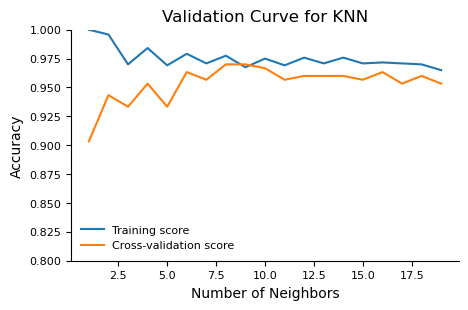

In [8]:
from sklearn.model_selection import validation_curve

# Définir le modèle et le paramètre à valider
model = KNeighborsClassifier()
param_name = 'n_neighbors'
param_range = np.arange(1, 20)

# Calculer la courbe de validation
train_scores, test_scores = validation_curve(
    model, X, y, param_name=param_name, param_range=param_range, cv=5, scoring='accuracy'
)

# Tracer la courbe de validation
plt.figure(figsize=(5, 3))
plt.plot(param_range, np.mean(train_scores, axis=1), label='Training score')
plt.plot(param_range, np.mean(test_scores, axis=1), label='Cross-validation score')
plt.xlabel('Number of Neighbors')
plt.ylabel('Accuracy')
plt.title('Validation Curve for KNN')
plt.ylim(0.8, 1.0)
plt.legend()
plt.show()

Perceptron for 2 classes

Accuracy: 0.95


Text(12.222222222222223, 0.5, 'True')

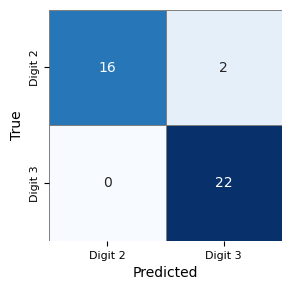

In [9]:
## MLP for N neurons and 2 classes
### using sklearn Perceptron

from sklearn.linear_model import Perceptron

X=UnitPop[0:200,:] # use all neurons as features

y=StimTarget[0:200] # to have labels 0,1,2,3 instead of 2,3,4,5

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Create and train the Perceptron model
perceptron = Perceptron(random_state=15, max_iter=5000) # increase max_iter if not converged
perceptron.fit(X_train, y_train)

# Make predictions on the test set
y_pred = perceptron.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(3,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,linewidths=0.5, linecolor='gray',xticklabels=['Digit 2', 'Digit 3'], yticklabels=['Digit 2', 'Digit 3'])
ax.set_xlabel('Predicted')
ax.set_ylabel('True')





MLP 3 classes

In [10]:
## MLP for N neurons and 4 classes
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


X=UnitPop

y=StimTarget

AccScore_MLP=[]
CM_NN=np.zeros((3,3))
split=0
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8,test_size=0.2, random_state=split)

model = Sequential()

model.add(Dense(X_train.shape[1], activation='relu', input_shape=(X_train.shape[1],)))
# model.add(Dense(32, activation='relu'))
model.add(Dense(3, activation='softmax'))

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
# Keras expects array-like labels and class indices starting at 0 for sparse_categorical_crossentropy
X_train = np.asarray(X_train, dtype=np.float32)
X_test = np.asarray(X_test, dtype=np.float32)
y_train = np.asarray(y_train, dtype=np.int32) - 2   # 2,3,4 -> 0,1,2
y_test = np.asarray(y_test, dtype=np.int32) - 2

model.fit(X_train, y_train, epochs=100, verbose=1, batch_size=32)

history = model.history.history
y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)
AccScore_MLP.append(accuracy_score(y_test, y_pred))

loss, accuracy = model.evaluate(X_test, y_test, verbose=1)
accuracy = accuracy * 100
print(f'Test accuracy: {accuracy:.2f}%')
print(f'loss: {loss:.4f}')

cm=confusion_matrix(y_test, y_pred)
CM_NN += cm

model.summary()

Epoch 1/100
8/8 [==============================] - 1s 9ms/step - loss: 0.6323 - accuracy: 0.7542
Epoch 2/100
8/8 [==============================] - 0s 9ms/step - loss: 0.0368 - accuracy: 1.0000
Epoch 3/100
8/8 [==============================] - 0s 9ms/step - loss: 0.0066 - accuracy: 1.0000
Epoch 4/100
8/8 [==============================] - 0s 9ms/step - loss: 0.0019 - accuracy: 1.0000
Epoch 5/100
8/8 [==============================] - 0s 9ms/step - loss: 0.0010 - accuracy: 1.0000
Epoch 6/100
8/8 [==============================] - 0s 8ms/step - loss: 7.4800e-04 - accuracy: 1.0000
Epoch 7/100
8/8 [==============================] - 0s 9ms/step - loss: 6.2280e-04 - accuracy: 1.0000
Epoch 8/100
8/8 [==============================] - 0s 8ms/step - loss: 5.4530e-04 - accuracy: 1.0000
Epoch 9/100
8/8 [==============================] - 0s 8ms/step - loss: 4.9859e-04 - accuracy: 1.0000
Epoch 10/100
8/8 [==============================] - 0s 9ms/step - loss: 4.6456e-04 - accuracy: 1.0000
Epoch 11/